# Import Modules

In [4]:
import os
import glob
import librosa
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Flatten, BatchNormalization
from tensorflow.keras.optimizers import RMSprop
from sklearn.metrics import classification_report, confusion_matrix
import warnings
warnings.filterwarnings("ignore")

# Data Loading and Feature Extraction

In [1]:
DATA_PATH = r"C:\Users\asus\OneDrive\Desktop\Projects\Speech_Emotion_Recognition_LSTM_RAVDESS\RAVDESS"

# Extract features and labels from the directory

def extract_mfcc(file_path):
    # Load audio and extract 180 features (MFCC + Delta + Delta2)
    y, sr = librosa.load(file_path, duration=3, offset=0.5)
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=60)
    # Mean of MFCCs across time to get a fixed vector of 60
    # To reach 180, we stack MFCC, Delta, and Delta-Delta
    mfcc_mean = np.mean(mfcc.T, axis=0)
    delta = librosa.feature.delta(mfcc)
    delta_mean = np.mean(delta.T, axis=0)
    delta2 = librosa.feature.delta(mfcc, order=2)
    delta2_mean = np.mean(delta2.T, axis=0)
    
    return np.hstack([mfcc_mean, delta_mean, delta2_mean])

# Full RAVDESS emotion mapping (01 to 08)
EMOTION_MAP = {
    '01': 'neutral',
    '02': 'calm',
    '03': 'happy',
    '04': 'sad',
    '05': 'angry',
    '06': 'fearful',
    '07': 'disgust',
    '08': 'surprised'
}

def load_data(data_path):
    X_list, y_list = [], []
    
    # Use glob to find all .wav files in Actor subfolders
    search_path = os.path.join(data_path, "Actor_*", "*.wav")
    file_list = glob.glob(search_path)
    
    print(f"Found {len(file_list)} audio files. Starting feature extraction...")

    for file in file_list:
        # Get filename and split by '-' to find the emotion code
        # RAVDESS format: 03-01-XX-01-01-01-XX.wav (Index 2 is the emotion)
        filename = os.path.basename(file)
        emotion_code = filename.split('-')[2]
        
        # Filter for your specific target emotions
        if emotion_code in EMOTION_MAP:
            features = extract_mfcc(file)
            X_list.append(features)
            y_list.append(EMOTION_MAP[emotion_code])
            
    return np.array(X_list), np.array(y_list)


In [7]:
X_raw, y_raw = load_data(DATA_PATH)

# Reshape for LSTM: (samples, time_steps, features)
# Standard practice is (N, 1, 180) for single-frame feature vectors
X = np.expand_dims(X_raw, axis=1)

# Encode Labels
lb = LabelEncoder()
y_encoded = to_categorical(lb.fit_transform(y_raw))

# Train-Test Split (0.25)
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.25, random_state=42)

print(f"Data loaded: X_train shape {X_train.shape}, y_train shape {y_train.shape}")


Found 1440 audio files. Starting feature extraction...
Data loaded: X_train shape (1080, 1, 180), y_train shape (1080, 8)


# Create the LSTM Model

In [11]:
model = Sequential()

# 1st LSTM Layer (with Batch Normalization)
model.add(BatchNormalization(input_shape=(1, 180)))
model.add(LSTM(128, return_sequences=True, activation='tanh'))
model.add(Dropout(0.1))

# 2nd LSTM Layer
model.add(LSTM(64, return_sequences=True, activation='tanh'))
model.add(Dropout(0.1))

# 3rd LSTM Layer
model.add(LSTM(32, return_sequences=True, activation='tanh'))
model.add(Dropout(0.2))

# Output Pipeline
model.add(Flatten())
model.add(Dense(64, activation='relu'))
model.add(Dense(8, activation='softmax')) # Output Layer (4 emotions)

# Optimizer & Loss
optimizer = RMSprop(learning_rate=0.001)
model.compile(loss='categorical_crossentropy', optimizer=optimizer, metrics=['accuracy'])

model.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ batch_normalization_1           │ (None, 1, 180)         │           720 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 1, 128)         │       158,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 1, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_4 (LSTM)                   │ (None, 1, 64)          │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 1, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (None, 1, 32)          │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 1, 32)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 8)              │           520 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 223,384 (872.59 KB)

 Trainable params: 223,024 (871.19 KB)

 Non-trainable params: 360 (1.41 KB)

In [15]:
# Training
history = model.fit(X_train, y_train, 
                    epochs=200, 
                    batch_size=32, 
                    validation_data=(X_test, y_test))


Epoch 1/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.9593 - loss: 0.1318 - val_accuracy: 0.4917 - val_loss: 2.8749
Epoch 2/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9639 - loss: 0.1130 - val_accuracy: 0.5361 - val_loss: 2.9301
Epoch 3/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9583 - loss: 0.1453 - val_accuracy: 0.4944 - val_loss: 3.0716
Epoch 4/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9574 - loss: 0.1179 - val_accuracy: 0.5139 - val_loss: 3.0063
Epoch 5/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9685 - loss: 0.0816 - val_accuracy: 0.5250 - val_loss: 3.0387
Epoch 6/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9648 - loss: 0.1103 - val_accuracy: 0.5028 - val_loss: 3.2405
Epoch 7/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.9648 - loss: 0.1068 - val_accuracy: 0.5000 - val_loss: 3.0818
Epoch 8/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.9676 - loss: 0.0932 - val_accuracy: 0.

# Plot the Results

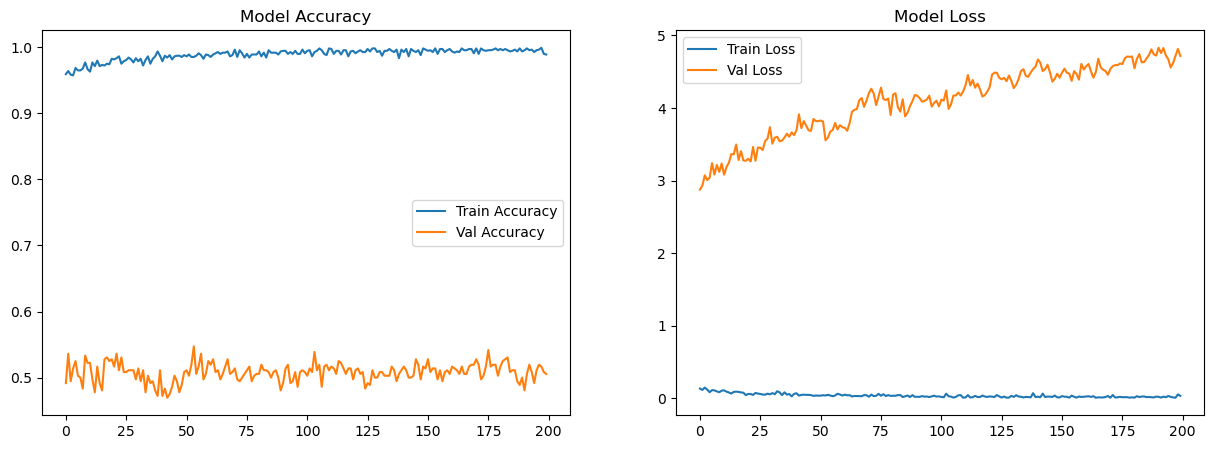

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 


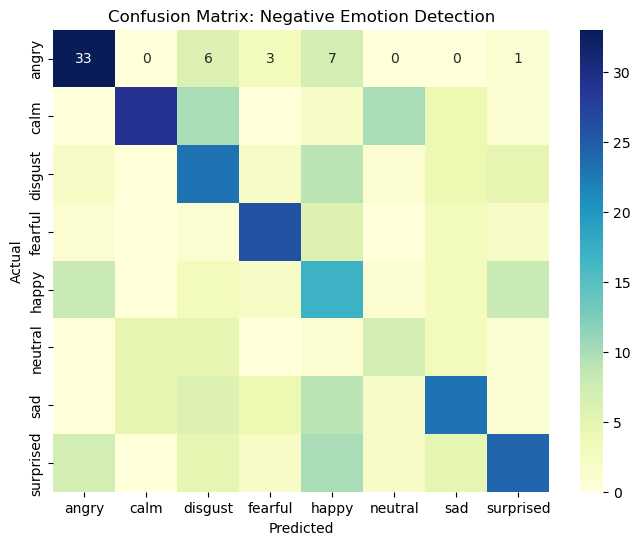


Classification Report:

              precision    recall  f1-score   support

       angry       0.65      0.66      0.65        50
        calm       0.74      0.52      0.61        56
     disgust       0.39      0.50      0.44        46
     fearful       0.67      0.67      0.67        39
       happy       0.28      0.40      0.33        42
     neutral       0.30      0.32      0.31        22
         sad       0.51      0.46      0.48        50
   surprised       0.56      0.44      0.49        55

    accuracy                           0.51       360
   macro avg       0.51      0.50      0.50       360
weighted avg       0.53      0.51      0.51       360



In [16]:
fig, ax = plt.subplots(1, 2, figsize=(15, 5))

ax[0].plot(history.history['accuracy'], label='Train Accuracy')
ax[0].plot(history.history['val_accuracy'], label='Val Accuracy')
ax[0].set_title('Model Accuracy')
ax[0].legend()

ax[1].plot(history.history['loss'], label='Train Loss')
ax[1].plot(history.history['val_loss'], label='Val Loss')
ax[1].set_title('Model Loss')
ax[1].legend()
plt.show()

# Confusion Matrix
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)

plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_true, y_pred_classes)
sns.heatmap(cm, annot=True, fmt='d', xticklabels=lb.classes_, yticklabels=lb.classes_, cmap='YlGnBu')
plt.title('Confusion Matrix: Negative Emotion Detection')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Classification Report
print("\nClassification Report:\n")
print(classification_report(y_true, y_pred_classes, target_names=lb.classes_))


In [17]:
# Evaluate the model on the test set
loss, accuracy = model.evaluate(X_test, y_test, verbose=1)

print(f"Test Accuracy: {accuracy * 100:.2f}%")
print(f"Test Loss: {loss:.4f}")


12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5056 - loss: 4.7183 
Test Accuracy: 50.56%
Test Loss: 4.7183
